In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
ds = xr.open_dataset("/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 2/DATA/Datos_raw.nc")  # cambia el nombre si es necesario
ds


<xarray.Dataset> Size: 440kB
Dimensions:     (valid_time: 420, latitude: 8, longitude: 8)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1991-01-01 ... 2025-12-01
    expver      (valid_time) <U4 7kB ...
  * latitude    (latitude) float64 64B 5.25 5.0 4.75 4.5 4.25 4.0 3.75 3.5
  * longitude   (longitude) float64 64B -76.25 -76.0 -75.75 ... -74.75 -74.5
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 108kB ...
    v10         (valid_time, latitude, longitude) float32 108kB ...
    t2m         (valid_time, latitude, longitude) float32 108kB ...
    sp          (valid_time, latitude, longitude) float32 108kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-21T01:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
ds.dims

FrozenMappingWarningOnValuesAccess({'valid_time': 420, 'latitude': 8, 'longitude': 8})

In [4]:
# Renombrar para trabajar más cómodo
ds = ds.rename({"valid_time": "time"})
ds

<xarray.Dataset> Size: 440kB
Dimensions:    (time: 420, latitude: 8, longitude: 8)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1991-01-01 1991-02-01 ... 2025-12-01
    expver     (time) <U4 7kB ...
  * latitude   (latitude) float64 64B 5.25 5.0 4.75 4.5 4.25 4.0 3.75 3.5
  * longitude  (longitude) float64 64B -76.25 -76.0 -75.75 ... -74.75 -74.5
    number     int64 8B ...
Data variables:
    u10        (time, latitude, longitude) float32 108kB ...
    v10        (time, latitude, longitude) float32 108kB ...
    t2m        (time, latitude, longitude) float32 108kB ...
    sp         (time, latitude, longitude) float32 108kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-21T01:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
ds_clim = ds.mean(dim="time")

u10 = ds_clim["u10"]
v10 = ds_clim["v10"]
t2m = ds_clim["t2m"]
sp = ds_clim["sp"]
t2m_C = t2m - 273.15
sp_hPa = sp / 100

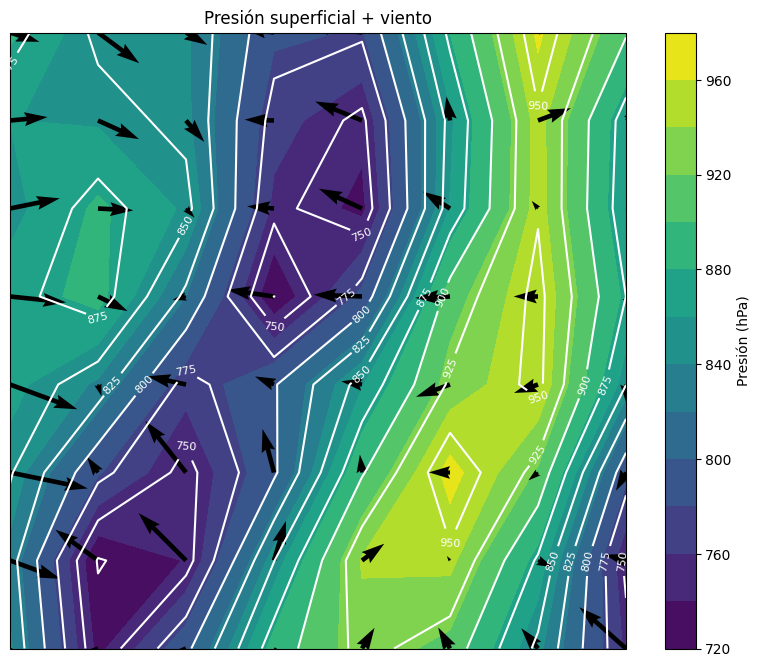

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

# Presión
cf = ax.contourf(sp_hPa.longitude, sp_hPa.latitude, sp_hPa,
                 cmap="viridis", levels=15)

# Isobaras
cs = ax.contour(sp_hPa.longitude, sp_hPa.latitude, sp_hPa,
                colors='white', levels=10)
ax.clabel(cs, fontsize=8)

# Viento
skip = 1  # ⚠️ como solo tienes 8x8, no saltes mucho
ax.quiver(u10.longitude, u10.latitude,
          u10.values, v10.values,
          color='black')

plt.colorbar(cf, label="Presión (hPa)")
plt.title("Presión superficial + viento")
plt.show()

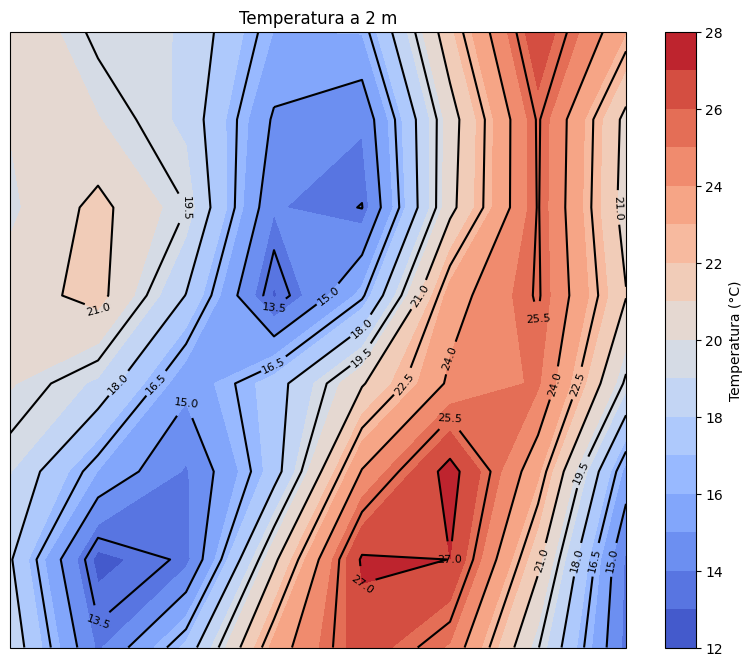

In [7]:
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

cf = ax.contourf(t2m_C.longitude, t2m_C.latitude, t2m_C,
                 cmap="coolwarm", levels=15)

cs = ax.contour(t2m_C.longitude, t2m_C.latitude, t2m_C,
                colors='black', levels=10)
ax.clabel(cs, fontsize=8)

plt.colorbar(cf, label="Temperatura (°C)")
plt.title("Temperatura a 2 m")
plt.show()

In [8]:
import numpy as np

Omega = 7.2921e-5
R = 287

lat = np.deg2rad(sp.latitude)

f = 2 * Omega * np.sin(lat)

rho = sp / (R * t2m)

In [9]:
# Convertir grados a metros
lat = np.deg2rad(sp.latitude)

dx = 111e3 * np.cos(lat)  # depende de latitud
dy = 111e3                # constante

# Gradientes con xarray (MUCHO más seguro)
dp_dx = sp.differentiate("longitude") / dx
dp_dy = sp.differentiate("latitude") / dy

In [10]:
f_2d = f
rho_2d = rho

ug = -1/(f_2d * rho_2d) * dp_dy
vg =  1/(f_2d * rho_2d) * dp_dx

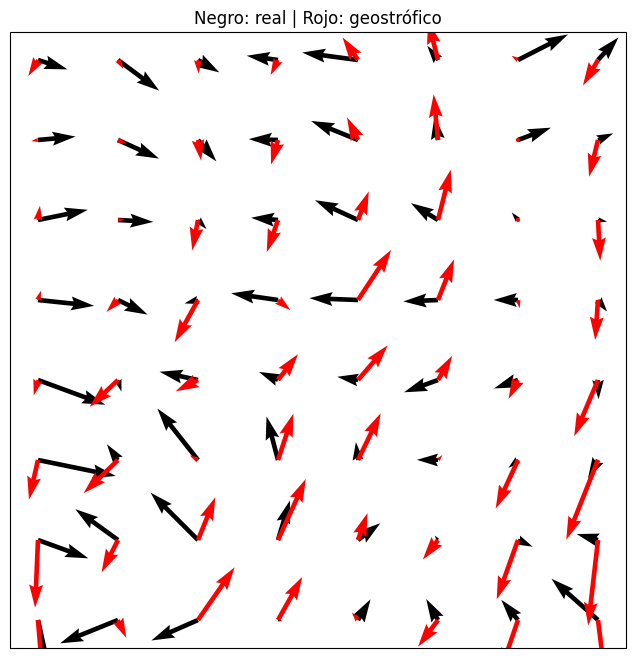

In [11]:
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)

ax.quiver(u10.longitude, u10.latitude,
          u10.values, v10.values,
          color='black')

ax.quiver(u10.longitude, u10.latitude,
          ug, vg,
          color='red')

plt.title("Negro: real | Rojo: geostrófico")
plt.show()

In [12]:
rmse = np.sqrt(((u10.values - ug)**2 + (v10.values - vg)**2).mean())
print("RMSE:", rmse)

RMSE: <xarray.DataArray ()> Size: 8B
array(24825.47611192)
Coordinates:
    number   int64 8B 0
Attributes: (12/27)
    units:                                    degrees_north
    standard_name:                            latitude
    long_name:                                latitude
    stored_direction:                         decreasing
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      64
    ...                                       ...
    GRIB_latitudeOfLastGridPointInDegrees:    3.5
    GRIB_longitudeOfFirstGridPointInDegrees:  -76.25
    GRIB_longitudeOfLastGridPointInDegrees:   -74.5
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0
    GRIB_surface:                             0.0


In [13]:
print(float(rmse))

24825.476111921085


In [14]:
# ============================================================
# Celda 1: Importación y carga de datos
# ============================================================

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray  # para exportar GeoTIFF
import rasterio
from scipy.interpolate import interp1d
import os

# Configuración de gráficos no cartográficos
plt.style.use('default')
%matplotlib inline

# -----------------------------------------------------------------
# Cargar el archivo NetCDF único (ajusta la ruta)
# -----------------------------------------------------------------
ruta_archivo = '/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 2/DATA/Datos_raw.nc'   # <--- Cambia por la ruta real
ds = xr.open_dataset(ruta_archivo)

print("Variables disponibles:")
print(list(ds.variables))

# -----------------------------------------------------------------
# Manejo de dimensiones
# -----------------------------------------------------------------
# Renombrar valid_time a time si existe
if 'valid_time' in ds.dims:
    ds = ds.rename({'valid_time': 'time'})

# Promediar sobre 'number' si existe (miembros de ensamble)
if 'number' in ds.dims:
    print(f"Promediando sobre {ds.dims['number']} miembros de ensamble...")
    ds = ds.mean(dim='number', keep_attrs=True)

# Seleccionar expver si existe
if 'expver' in ds.coords:
    ds = ds.sel(expver=ds.expver.values[0])

# -----------------------------------------------------------------
# Calcular climatología (promedio temporal)
# -----------------------------------------------------------------
clim = ds.mean(dim='time', keep_attrs=True)

# Convertir unidades
t2m = clim.t2m - 273.15      # °C
sp = clim.sp / 100            # hPa
u10 = clim.u10
v10 = clim.v10

# Asegurar que las coordenadas tengan nombre estándar
if 'longitude' in t2m.dims and 'latitude' in t2m.dims:
    t2m = t2m.rename({'longitude': 'x', 'latitude': 'y'})
    sp = sp.rename({'longitude': 'x', 'latitude': 'y'})
    u10 = u10.rename({'longitude': 'x', 'latitude': 'y'})
    v10 = v10.rename({'longitude': 'x', 'latitude': 'y'})

print("\nClimatología calculada:")
print(f"Temperatura: {t2m.shape}, unidades: °C")
print(f"Presión: {sp.shape}, unidades: hPa")
print(f"Viento u10: {u10.shape}, unidades: m/s")
print(f"Viento v10: {v10.shape}, unidades: m/s")

Variables disponibles:
['u10', 'v10', 't2m', 'sp', 'number', 'valid_time', 'latitude', 'longitude', 'expver']

Climatología calculada:
Temperatura: (8, 8), unidades: °C
Presión: (8, 8), unidades: hPa
Viento u10: (8, 8), unidades: m/s
Viento v10: (8, 8), unidades: m/s


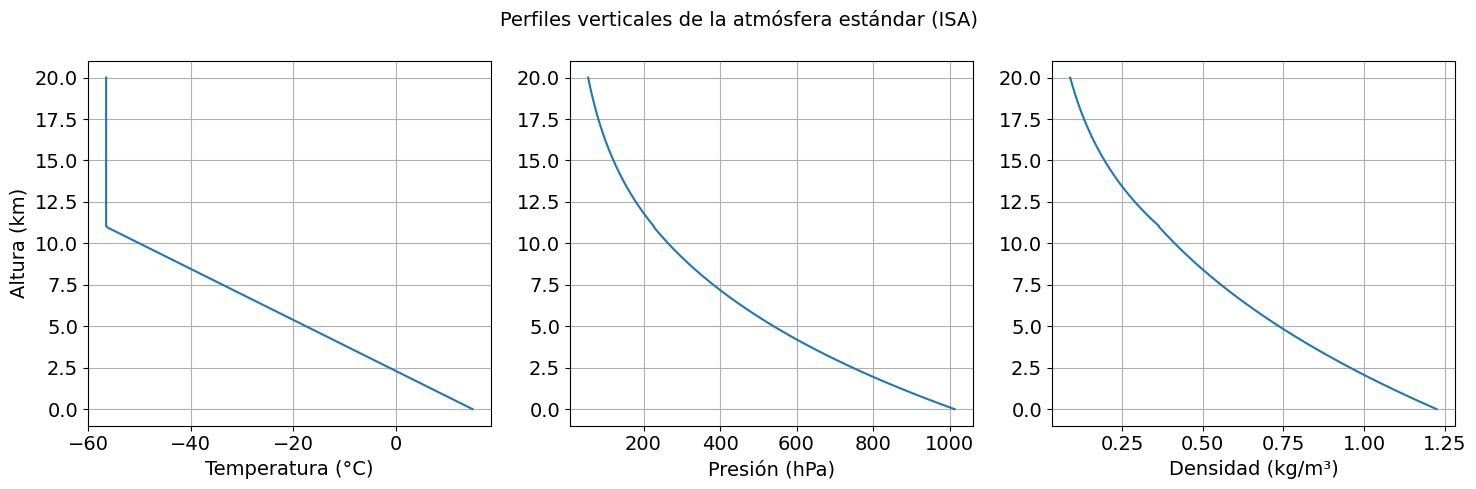

In [15]:
# ============================================================
# Celda 2: Perfiles verticales de atmósfera estándar
# ============================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 14
})
z = np.linspace(0, 20000, 200)
g = 9.80665
R = 287.05
gamma = 0.0065
T0 = 288.15
P0 = 101325
rho0 = 1.225

z_tropo = z[z <= 11000]
T_tropo = T0 - gamma * z_tropo
P_tropo = P0 * (T_tropo / T0) ** (g / (R * gamma))
rho_tropo = rho0 * (T_tropo / T0) ** ((g / (R * gamma)) - 1)

z_strato = z[z > 11000]
T_strato = 216.65 * np.ones_like(z_strato)
P_strato = P_tropo[-1] * np.exp(-g / (R * 216.65) * (z_strato - 11000))
rho_strato = P_strato / (R * 216.65)

z_full = np.concatenate([z_tropo, z_strato])
T_full = np.concatenate([T_tropo, T_strato])
P_full = np.concatenate([P_tropo, P_strato])
rho_full = np.concatenate([rho_tropo, rho_strato])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(T_full - 273.15, z_full/1000)
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Altura (km)')
axes[0].grid(True)
axes[1].plot(P_full/100, z_full/1000)
axes[1].set_xlabel('Presión (hPa)')
axes[1].grid(True)
axes[2].plot(rho_full, z_full/1000)
axes[2].set_xlabel('Densidad (kg/m³)')
axes[2].grid(True)
plt.suptitle('Perfiles verticales de la atmósfera estándar (ISA)')
plt.tight_layout()
#plt.savefig('perfil_isa.png', dpi=150)
plt.show()

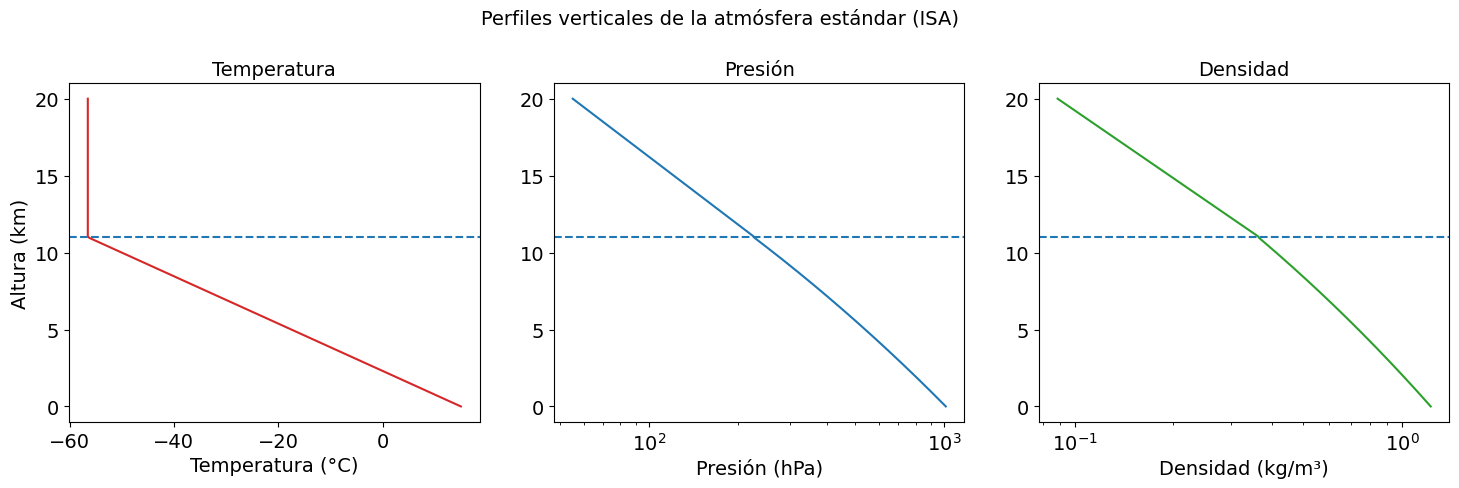

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ======================
# TEMPERATURA
# ======================
axes[0].plot(T_full - 273.15, z_full/1000, color='tab:red')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Altura (km)')
axes[0].set_title('Temperatura')
#axes[0].grid(True)

# Línea tropopausa
axes[0].axhline(11, linestyle='--')

# ======================
# PRESIÓN
# ======================
axes[1].plot(P_full/100, z_full/1000, color='tab:blue')
axes[1].set_xlabel('Presión (hPa)')
axes[1].set_title('Presión')
axes[1].set_xscale('log')   # 🔥 MUY IMPORTANTE
#axes[1].grid(True)
axes[1].axhline(11, linestyle='--')

# ======================
# DENSIDAD
# ======================
axes[2].plot(rho_full, z_full/1000, color='tab:green')
axes[2].set_xlabel('Densidad (kg/m³)')
axes[2].set_title('Densidad')
axes[2].set_xscale('log')   # 🔥 MUY IMPORTANTE
#axes[2].grid(True)
axes[2].axhline(11, linestyle='--')

plt.suptitle('Perfiles verticales de la atmósfera estándar (ISA)', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Ruta del archivo descargado
ds = xr.open_dataset("/home/santiago/Escritorio/UNIVERSIDAD/FISICA_DEL_CLIMA/F-sica-del-Clima/proyecto 2/DATA/Datos2_raw.nc")

print(ds)
print("\nDimensiones:", ds.dims)

<xarray.Dataset> Size: 8MB
Dimensions:         (valid_time: 396, pressure_level: 37, latitude: 8,
                     longitude: 8)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 3kB 1993-01-01 ... 2025-12-01
    expver          (valid_time) <U4 6kB ...
  * pressure_level  (pressure_level) float64 296B 1e+03 975.0 950.0 ... 2.0 1.0
  * latitude        (latitude) float64 64B 5.25 5.0 4.75 4.5 4.25 4.0 3.75 3.5
  * longitude       (longitude) float64 64B -76.25 -76.0 -75.75 ... -74.75 -74.5
    number          int64 8B ...
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 4MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecas

In [18]:
# Renombrar dimensión temporal si es necesario
if 'valid_time' in ds.dims:
    ds = ds.rename({'valid_time': 'time'})

# Promedio temporal (climatología)
clim = ds.mean(dim='time')

# Variables
T = clim['t']          # Kelvin
Z = clim['z']          # geopotential (m^2/s^2)

# Convertir geopotencial → altura (m)
g = 9.80665
z = Z / g

print(T.shape)

(37, 8, 8)


In [19]:
# Promedio sobre lat/lon → perfil vertical puro
T_prof = T.mean(dim=['latitude', 'longitude'])
z_prof = z.mean(dim=['latitude', 'longitude'])

# Convertir temperatura a °C
T_prof_C = T_prof - 273.15

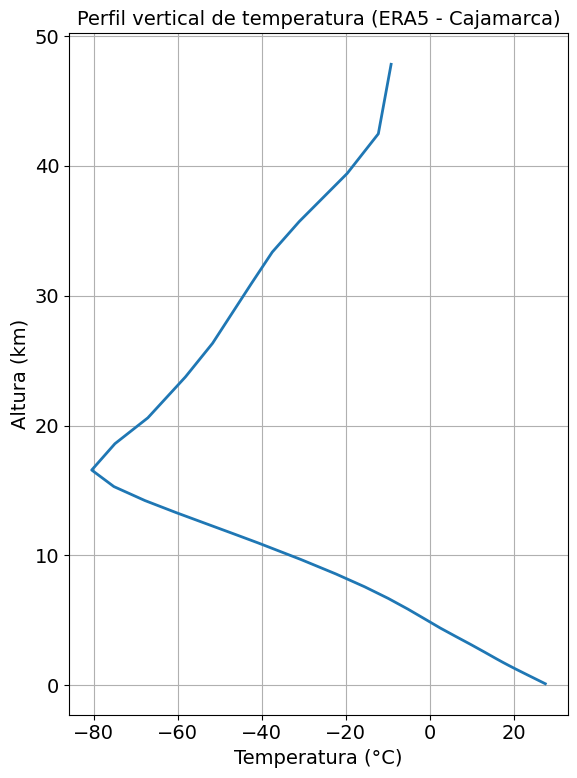

In [20]:
plt.figure(figsize=(6,8))

plt.plot(T_prof_C, z_prof/1000, linewidth=2)

plt.xlabel('Temperatura (°C)')
plt.ylabel('Altura (km)')
plt.title('Perfil vertical de temperatura (ERA5 - Cajamarca)')
plt.grid(True)

plt.tight_layout()
plt.savefig('perfil_vertical_era5.png', dpi=150)
plt.show()

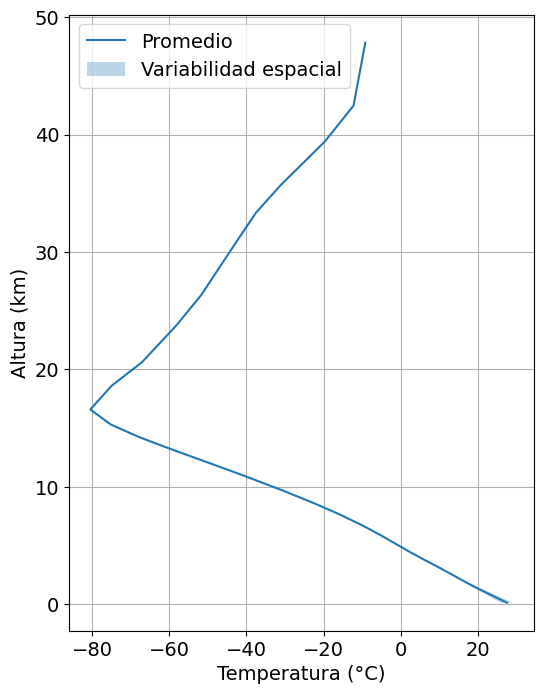

In [21]:
# Desviación estándar vertical
T_std = T.std(dim=['latitude', 'longitude'])

plt.figure(figsize=(6,8))

plt.plot(T_prof_C, z_prof/1000, label='Promedio')
plt.fill_betweenx(
    z_prof/1000,
    (T_prof - T_std - 273.15),
    (T_prof + T_std - 273.15),
    alpha=0.3,
    label='Variabilidad espacial'
)

plt.xlabel('Temperatura (°C)')
plt.ylabel('Altura (km)')
plt.legend()
plt.grid(True)

plt.savefig('perfil_con_variabilidad.png', dpi=150)
plt.show()

In [22]:
print("Max std dev:", T_std.max().values)

Max std dev: 1.5393887


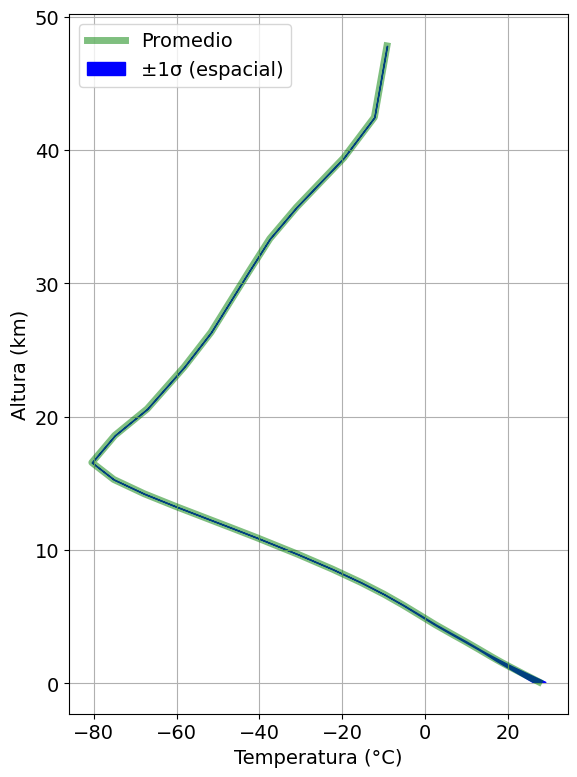

In [23]:
plt.figure(figsize=(6,8))
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 14
})
plt.plot(T_prof_C, z_prof/1000, linewidth=5, label='Promedio',color='green',alpha=0.5)
plt.fill_betweenx(z_prof/1000,
                  (T_prof - T_std - 273.15),
                  (T_prof + T_std - 273.15),
                  alpha=1, color='blue', label='±1σ (espacial)')
# Add dashed lines for bounds
#plt.plot((T_prof - T_std - 273.15), z_prof/1000, '--', color='red', linewidth=1)
#plt.plot((T_prof + T_std - 273.15), z_prof/1000, '--', color='red', linewidth=1)

plt.xlabel('Temperatura (°C)')
plt.ylabel('Altura (km)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('perfil_con_variabilidad.png', dpi=150)
plt.show()

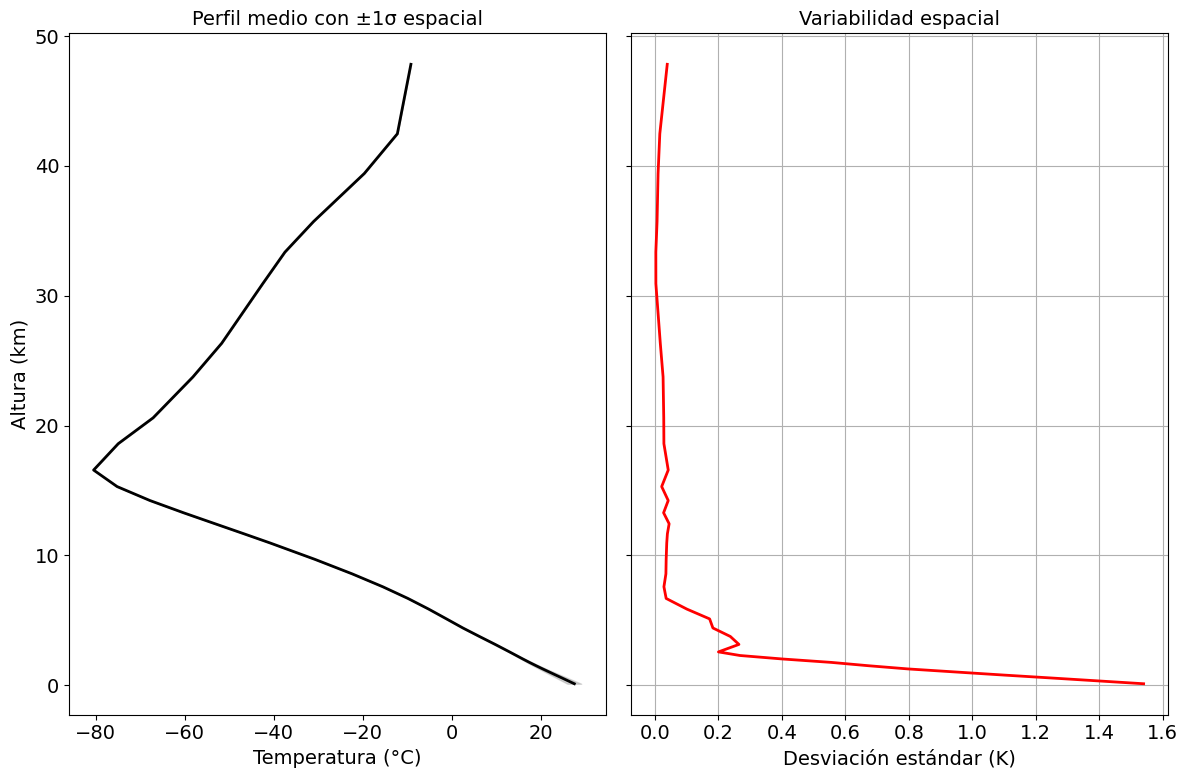

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

# Left: mean profile
ax1.plot(T_prof_C, z_prof/1000, 'k-', linewidth=2)
ax1.fill_betweenx(z_prof/1000,
                  (T_prof - T_std - 273.15),
                  (T_prof + T_std - 273.15),
                  alpha=0.3, color='gray')
ax1.set_xlabel('Temperatura (°C)')
ax1.set_ylabel('Altura (km)')
ax1.set_title('Perfil medio con ±1σ espacial')

# Right: standard deviation
ax2.plot(T_std, z_prof/1000, 'r-', linewidth=2)
ax2.set_xlabel('Desviación estándar (K)')
ax2.set_title('Variabilidad espacial')
ax2.grid(True)

plt.tight_layout()
#plt.savefig('perfil_variabilidad_separado.png', dpi=150)
plt.show()

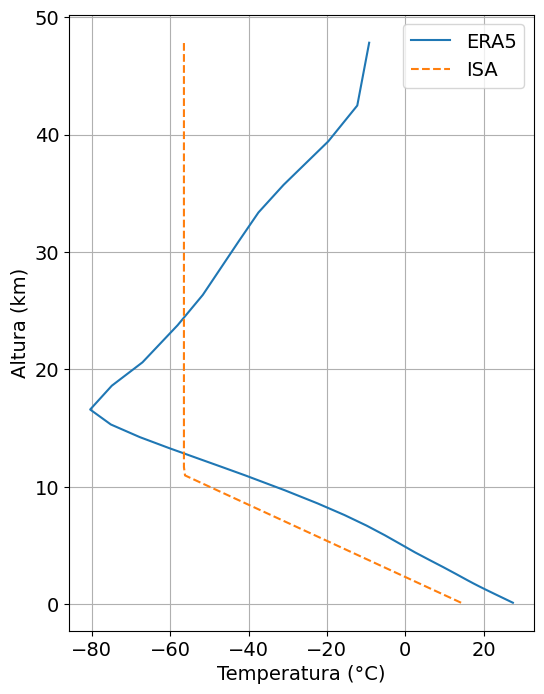

In [25]:
# Interpolar ISA a tus alturas
from scipy.interpolate import interp1d

interp_ISA = interp1d(z_full, T_full - 273.15, fill_value="extrapolate")

T_ISA_interp = interp_ISA(z_prof)
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 14
})
plt.figure(figsize=(6,8))

plt.plot(T_prof_C, z_prof/1000, label='ERA5')
plt.plot(T_ISA_interp, z_prof/1000, '--', label='ISA')

plt.xlabel('Temperatura (°C)')
plt.ylabel('Altura (km)')
plt.legend()
plt.grid(True)

plt.savefig('comparacion_ISA.png', dpi=150)
plt.show()

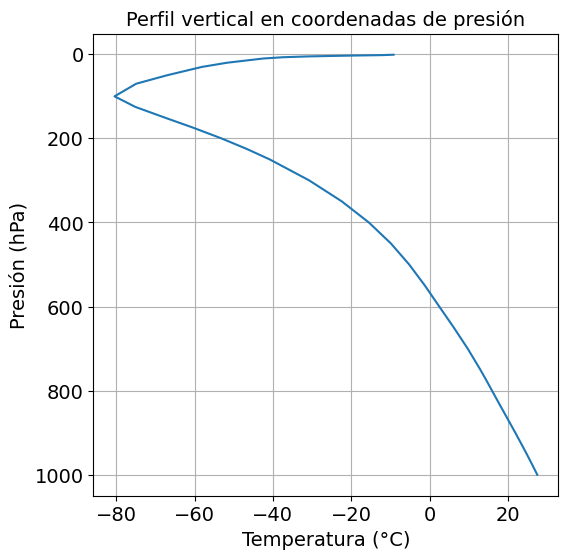

In [26]:
pressure = clim['pressure_level']

plt.figure(figsize=(6,6))

plt.plot(T_prof_C, pressure)

plt.gca().invert_yaxis()

plt.xlabel('Temperatura (°C)')
plt.ylabel('Presión (hPa)')
plt.title('Perfil vertical en coordenadas de presión')

plt.grid(True)
plt.savefig('perfil_presion.png', dpi=150)
plt.show()

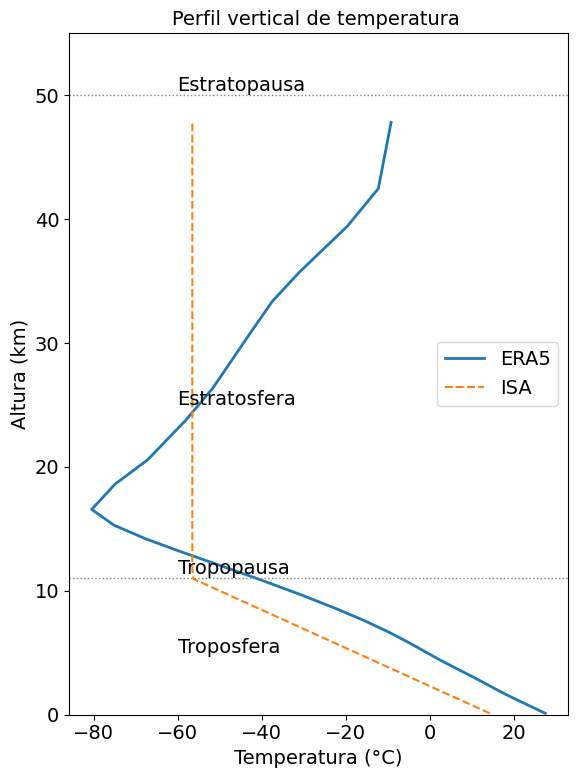

In [27]:
plt.figure(figsize=(6,8))

# Perfil ERA5
plt.plot(T_prof_C, z_prof/1000, linewidth=2, label='ERA5')

# ISA interpolada
plt.plot(T_ISA_interp, z_prof/1000, '--', label='ISA')

# -------------------------------
# Capas atmosféricas (hasta estratopausa)
# -------------------------------

# Límites (km)
tropopause = 11
stratopause = 50

# Líneas horizontales
plt.axhline(tropopause, color='gray', linestyle=':', linewidth=1)
plt.axhline(stratopause, color='gray', linestyle=':', linewidth=1)

# Regiones
plt.text(-60, 5, 'Troposfera')
plt.text(-60, 25, 'Estratosfera')

# Etiquetas de pausas
plt.text(-60, tropopause, 'Tropopausa', va='bottom')
plt.text(-60, stratopause, 'Estratopausa', va='bottom')

# -------------------------------

plt.xlabel('Temperatura (°C)')
plt.ylabel('Altura (km)')
plt.title('Perfil vertical de temperatura ')
plt.legend()
#plt.grid(True)

# Limitar eje vertical (opcional pero recomendado)
plt.ylim(0, 55)

plt.tight_layout()
plt.savefig('perfil_capas.png', dpi=150)
plt.show()

In [28]:
# ============================================================
# Métricas adicionales para el viento geostrófico (superficie)
# ============================================================

import numpy as np
from scipy.stats import pearsonr

# Aplanar los datos para calcular correlaciones (ignorar NaNs si los hay)
u10_flat = u10.values.flatten()
v10_flat = v10.values.flatten()
ug_flat = ug.values.flatten()
vg_flat = vg.values.flatten()

# Correlación por componente
corr_u, p_u = pearsonr(u10_flat, ug_flat)
corr_v, p_v = pearsonr(v10_flat, vg_flat)

# Diferencia angular media (en grados)
# Producto punto y normas
dot = u10.values * ug.values + v10.values * vg.values
norm_real = np.sqrt(u10.values**2 + v10.values**2)
norm_geo = np.sqrt(ug.values**2 + vg.values**2)

# Ángulo entre vectores (evitar división por cero)
cos_theta = np.divide(dot, norm_real * norm_geo, out=np.zeros_like(dot), where=(norm_real * norm_geo) > 0)
cos_theta = np.clip(cos_theta, -1, 1)
angulo = np.arccos(cos_theta) * (180 / np.pi)  # grados

# Promedio de la diferencia angular (excluyendo puntos donde alguno de los vectores es nulo)
mask = (norm_real > 0) & (norm_geo > 0)
angulo_mean = np.mean(angulo[mask])

print(f"Correlación u10 vs ug: {corr_u:.3f} (p={p_u:.3e})")
print(f"Correlación v10 vs vg: {corr_v:.3f} (p={p_v:.3e})")
print(f"Diferencia angular media: {angulo_mean:.1f}°")

Correlación u10 vs ug: -0.130 (p=3.075e-01)
Correlación v10 vs vg: 0.387 (p=1.601e-03)
Diferencia angular media: 77.1°


In [34]:
# ============================================================
# Tabla resumen de métricas
# ============================================================

print("\n=== Resumen de métricas ===")
print(f"RMSE (superficie):                 {rmse:.2f} m/s")
print(f"Correlación u10 vs ug:             {corr_u:.3f}")
print(f"Correlación v10 vs vg:             {corr_v:.3f}")
print(f"Diferencia angular media (sup):    {angulo_mean:.1f}°")
#print(f"\nRMSE ({level_actual} hPa):                {rmse_p:.2f} m/s")
#print(f"Correlación u real vs ug ({level_actual} hPa): {corr_u_p:.3f}")
#print(f"Correlación v real vs vg ({level_actual} hPa): {corr_v_p:.3f}")
#print(f"Diferencia angular media ({level_actual} hPa): {angulo_mean_p:.1f}°")


=== Resumen de métricas ===
RMSE (superficie):                 24825.48 m/s
Correlación u10 vs ug:             -0.130
Correlación v10 vs vg:             0.387
Diferencia angular media (sup):    77.1°
